In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.4 MB/s eta 0:00:00


In [3]:
pip install tensorflow

In [4]:
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Nadam

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [5]:
data = pd.read_csv(r'/content/Salary_Data.csv')
data

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [6]:
data.describe(include='all')

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
count,6702.000000,6702,6701,6702,6701.000000,6699.000000
unique,NaN,3,7,193,NaN,NaN
top,NaN,Male,Bachelor's Degree,Software Engineer,NaN,NaN
freq,NaN,3674,2267,518,NaN,NaN
mean,33.620859,NaN,NaN,NaN,8.094687,115326.964771
std,7.614633,NaN,NaN,NaN,6.059003,52786.183911
min,21.000000,NaN,NaN,NaN,0.000000,350.000000
25%,28.000000,NaN,NaN,NaN,3.000000,70000.000000
50%,32.000000,NaN,NaN,NaN,7.000000,115000.000000
75%,38.000000,NaN,NaN,NaN,12.000000,160000.000000


In [7]:
data.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


In [8]:
for i in data.columns:
  if data[i].dtypes != object:
    data[i].fillna(data[i].mean(), inplace=True)
  else:
    data[i].fillna(data[i].mode()[0], inplace=True)

/tmp/ipykernel_24058/429272540.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].fillna(data[i].mean(), inplace=True)
/tmp/ipykernel_24058/429272540.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [9]:
data['Education Level'].value_counts()

,count
Education Level,
Bachelor's Degree,2270
Master's Degree,1573
PhD,1368
Bachelor's,756
High School,448
Master's,288
phD,1


In [10]:
data['Education Level'] = np.where(data['Education Level']== 'phD', 'PhD', data['Education Level'])
data['Education Level'] = np.where(data['Education Level']== "Master's", "Master's Degree", data['Education Level'])
data['Education Level'] = np.where(data['Education Level']== "Bachelor's", "Bachelor's Degree", data['Education Level'])

In [11]:
data["is_mid_career"] = data["Age"].between(30, 45).astype(int)


In [12]:
edu_map = {
    "High School": 0,
    "Bachelor's Degree": 1,
    "Master's Degree":  2,
    "PhD":3,
}

data["edu_rank"] = data["Education Level"].map(edu_map)

data["modal_edu_in_title"] = (
    data.groupby("Job Title")["edu_rank"]
      .transform("median")
)


In [13]:
data.drop(data[['Education Level']], axis=1, inplace=True)

In [14]:
data

,Age,Gender,Job Title,Years of Experience,Salary,is_mid_career,edu_rank,modal_edu_in_title
0,32.0,Male,Software Engineer,5.0,90000.0,1,1,1.0
1,28.0,Female,Data Analyst,3.0,65000.0,0,2,1.0
2,45.0,Male,Senior Manager,15.0,150000.0,1,3,3.0
3,36.0,Female,Sales Associate,7.0,60000.0,1,1,0.0
4,52.0,Male,Director,20.0,200000.0,0,2,2.0
...,...,...,...,...,...,...,...,...
6699,49.0,Female,Director of Marketing,20.0,200000.0,0,3,2.0
6700,32.0,Male,Sales Associate,3.0,50000.0,1,0,0.0
6701,30.0,Female,Financial Manager,4.0,55000.0,1,1,1.0
6702,46.0,Male,Marketing Manager,14.0,140000.0,0,2,2.0


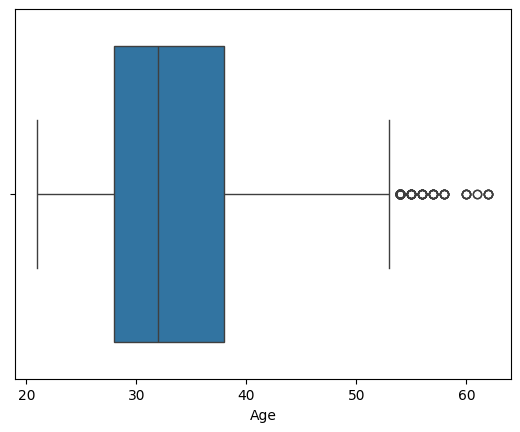

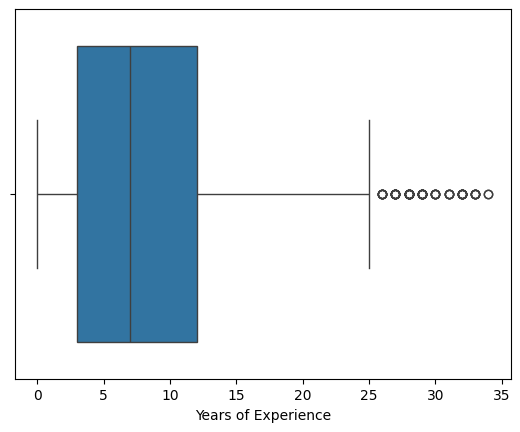

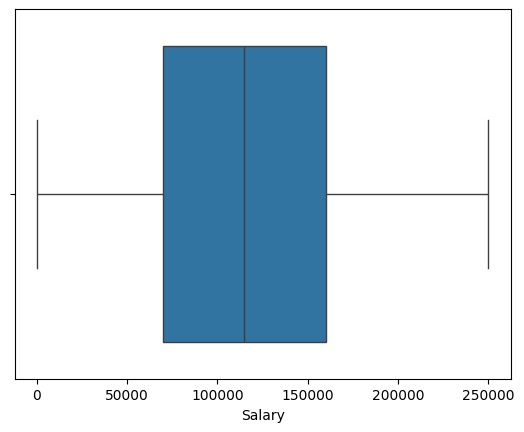

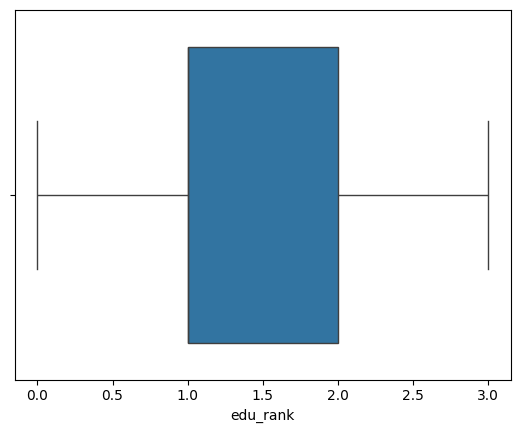

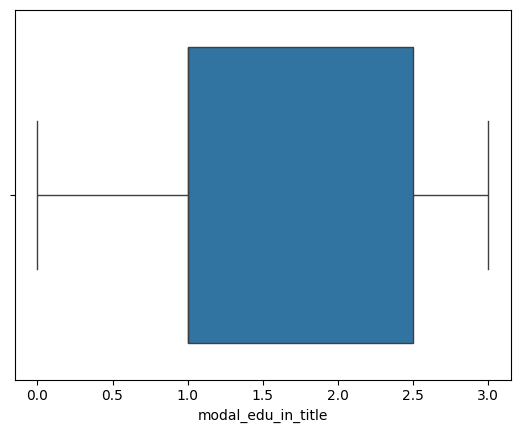

In [15]:
for i in data.columns:
  if data[i].dtypes != object and data[i].nunique() > 2:
    sns.boxplot(data=data, x=data[i])
    plt.show()

In [16]:
q1 = data.quantile(0.25, numeric_only=True)
q3 = data.quantile(0.75, numeric_only=True)

iqr= q3-q1
upper = q3 + 1.5*iqr
lower = q1 - 1.5*iqr

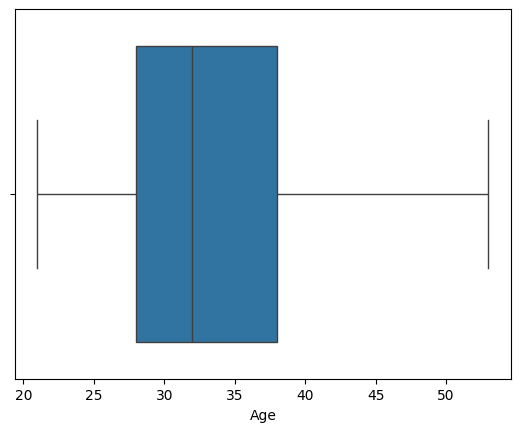

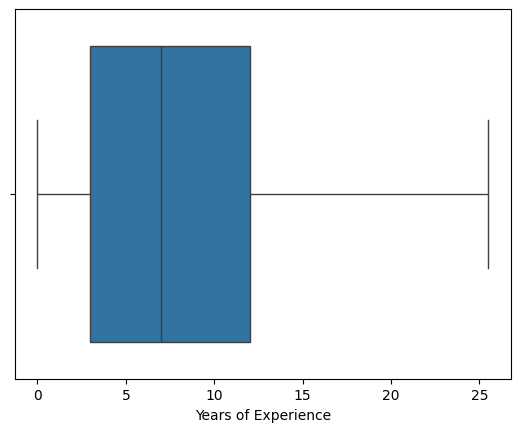

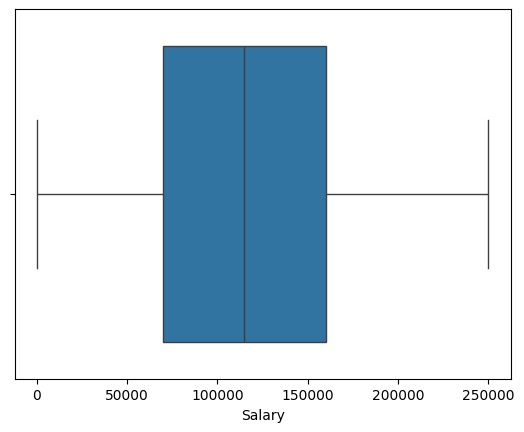

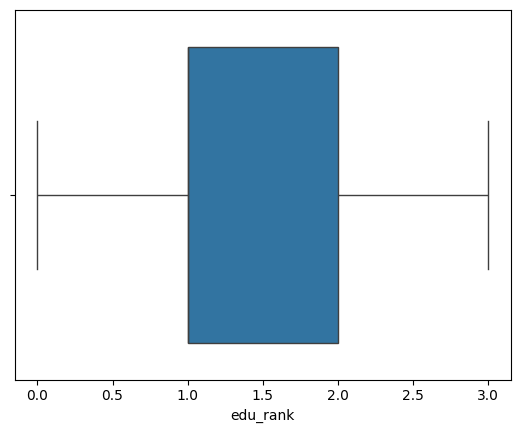

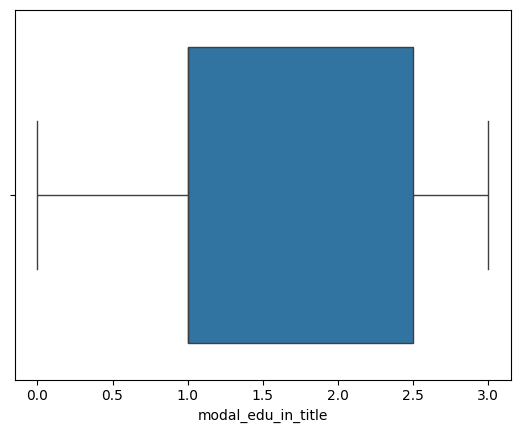

In [17]:
for i in data.columns:
  if data[i].dtypes != object and data[i].nunique()>2:
    data[i] = np.where(data[i]> upper[i], upper[i], data[i])
    data[i] = np.where(data[i]< lower[i], lower[i], data[i])
    sns.boxplot(data=data,x=data[i])
    plt.show()

In [18]:
data = pd.get_dummies(data, drop_first=True)

data

,Age,Years of Experience,Salary,is_mid_career,edu_rank,modal_edu_in_title,Gender_Male,Gender_Other,Job Title_Accountant,Job Title_Administrative Assistant,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,32.0,5.0,90000.0,1,1.0,1.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,28.0,3.0,65000.0,0,2.0,1.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,45.0,15.0,150000.0,1,3.0,3.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,36.0,7.0,60000.0,1,1.0,0.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,52.0,20.0,200000.0,0,2.0,2.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6699,49.0,20.0,200000.0,0,3.0,2.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6700,32.0,3.0,50000.0,1,0.0,0.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6701,30.0,4.0,55000.0,1,1.0,1.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6702,46.0,14.0,140000.0,0,2.0,2.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [19]:
targets = data['Salary']

inputs = data.drop(['Salary'],axis=1)

In [20]:
scaler = StandardScaler()
scaler.fit(inputs)

scaled = scaler.transform(inputs)

inputs_scaled = pd.DataFrame(scaled, columns=inputs.columns)

inputs_scaled

,Age,Years of Experience,is_mid_career,edu_rank,modal_edu_in_title,Gender_Male,Gender_Other,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Back end Developer,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,-0.210575,-0.515954,0.916371,-0.702050,-0.752972,0.907591,-0.045746,-0.012214,-0.017275,-0.194347,...,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.114665
1,-0.744992,-0.854019,-1.091261,0.431784,-0.752972,-1.101818,-0.045746,-0.012214,-0.017275,-0.194347,...,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.114665
2,1.526279,1.174370,0.916371,1.565617,1.449919,0.907591,-0.045746,-0.012214,-0.017275,-0.194347,...,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.114665
3,0.323842,-0.177890,0.916371,-0.702050,-1.854418,-1.101818,-0.045746,-0.012214,-0.017275,-0.194347,...,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.114665
4,2.461508,2.019532,-1.091261,0.431784,0.348473,0.907591,-0.045746,-0.012214,-0.017275,-0.194347,...,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.114665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6699,2.060696,2.019532,-1.091261,1.565617,0.348473,-1.101818,-0.045746,-0.012214,-0.017275,-0.194347,...,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.114665
6700,-0.210575,-0.854019,0.916371,-1.835883,-1.854418,0.907591,-0.045746,-0.012214,-0.017275,-0.194347,...,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.114665
6701,-0.477783,-0.684987,0.916371,-0.702050,-0.752972,-1.101818,-0.045746,-0.012214,-0.017275,-0.194347,...,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.114665
6702,1.659883,1.005337,-1.091261,0.431784,0.348473,0.907591,-0.045746,-0.012214,-0.017275,-0.194347,...,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.012214,-0.114665


In [21]:
X_train, X_test, y_train, y_test = train_test_split(inputs_scaled, targets, test_size=0.2, random_state=42)

In [22]:
def create_model(trial):

    model = Sequential()


    model.add(Dense(units=trial.suggest_int('units_layer1', 6, 32), activation='relu'))
    model.add(Dense(units=trial.suggest_int('units_layer2', 6, 32), activation='relu'))
    model.add(Dense(units=1, activation='relu'))


    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop', 'adagrad'])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    elif optimizer_name == 'adagrad':
        optimizer = Adagrad(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss='MAE', metrics=['MAE'])

    return model

In [37]:
def optimal(trial):


    epochs = trial.suggest_int('epochs', 10, 50)
    batch_size = trial.suggest_int('batch_size', 16, 64)

    model = create_model(trial)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size)

    y_pred = model.predict(X_test)
    r2 = metrics.r2_score(y_test, y_pred)

    return r2

study = optuna.create_study(direction='maximize')
study.optimize(optimal, n_trials=20)

print(f"Best trial: {study.best_trial.value}")
print(f"Best hyperparameters: {study.best_trial.params}")

[I 2026-05-12 11:26:33,926] A new study created in memory with name: no-name-9a35fee3-ec44-49e0-9519-b9ce5d9c6042


Epoch 1/29


/tmp/ipykernel_24058/2186030248.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)


163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - MAE: 115820.6172 - loss: 115820.6172
Epoch 2/29
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - MAE: 114541.1094 - loss: 114541.1094
Epoch 3/29
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - MAE: 108623.2031 - loss: 108623.2031
Epoch 4/29
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - MAE: 94367.7734 - loss: 94367.7734  
Epoch 5/29
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 69212.4844 - loss: 69212.4844
Epoch 6/29
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 38540.0859 - loss: 38540.0859
Epoch 7/29
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 26634.9336 - loss: 26634.9336
Epoch 8/29
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 23502.0352 - loss: 23502.0352
Epoch 9/29
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 21492.3535 - loss: 21492.3535
Epoch 10/29
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 20116.1777 - loss: 20116.1777
Epoch 11/29
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 19127.5918 - loss: 19127.5918
Epoch 12/29
163/163 ━━

[I 2026-05-12 11:26:53,044] Trial 0 finished with value: 0.6515661893596711 and parameters: {'epochs': 29, 'batch_size': 33, 'units_layer1': 15, 'units_layer2': 19, 'optimizer': 'adam', 'learning_rate': 0.0025291105154349913}. Best is trial 0 with value: 0.6515661893596711.


...

Epoch 1/33


/tmp/ipykernel_24058/2186030248.py:12: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)


102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - MAE: 115874.0859 - loss: 115874.0859
Epoch 2/33
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115868.2578 - loss: 115868.2578
Epoch 3/33
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 84153.5859 - loss: 84153.5859  
Epoch 4/33
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 57814.4062 - loss: 57814.4062
Epoch 5/33
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 51686.1758 - loss: 51686.1758
Epoch 6/33
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 45719.8477 - loss: 45719.8477
Epoch 7/33
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 41236.4766 - loss: 41236.4766
Epoch 8/33
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 40622.7344 - loss: 40622.7344
Epoch 9/33
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 37132.5078 - loss: 37132.5078
Epoch 10/33
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 33056.2500 - loss: 33056.2500
Epoch 11/33
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 32464.5469 - loss: 32464.5391
Epoch 12/33
102/102 ━━━━

[I 2026-05-12 11:33:02,511] Trial 19 finished with value: 0.2703776204111442 and parameters: {'epochs': 33, 'batch_size': 53, 'units_layer1': 19, 'units_layer2': 23, 'optimizer': 'sgd', 'learning_rate': 0.006695967444166389}. Best is trial 18 with value: 0.8779520118945827.


Best trial: 0.8779520118945827
Best hyperparameters: {'epochs': 44, 'batch_size': 39, 'units_layer1': 18, 'units_layer2': 19, 'optimizer': 'sgd', 'learning_rate': 0.0009538976090971923}


In [38]:
best_params = study.best_trial.params

best_params

{'epochs': 44,
 'batch_size': 39,
 'units_layer1': 18,
 'units_layer2': 19,
 'optimizer': 'sgd',
 'learning_rate': 0.0009538976090971923}

In [41]:
best_model = Sequential()
best_model.add(Dense(units=best_params['units_layer1'], activation='relu'))
best_model.add(Dense(units=best_params['units_layer2'], activation='relu'))
best_model.add(Dense(1, activation='relu'))

In [42]:
if best_params['optimizer'] == 'adam':
    best_optimizer = Adam(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'sgd':
    best_optimizer = SGD(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'rmsprop':
    best_optimizer = RMSprop(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'adagrad':
    best_optimizer = Adagrad(learning_rate=best_params['learning_rate'])

In [43]:
best_model.compile(optimizer=best_optimizer, loss='MAE', metrics=['MAE'])

In [44]:
def evaluate(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train, epochs=23, batch_size=best_params['batch_size'])


    y_train_prob = model.predict(X_train)


    y_test_prob = model.predict(X_test)

    r2_train = metrics.r2_score(y_train, y_train_prob)
    r2_test = metrics.r2_score(y_test, y_test_prob)


    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'R2 score': [r2_train*100, r2_test*100],

    })

    return results

In [45]:
evaluate(best_model, X_train, y_train, X_test, y_test)

Epoch 1/23
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 115874.0938 - loss: 115874.0938
Epoch 2/23
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - MAE: 115874.0547 - loss: 115874.0547
Epoch 3/23
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - MAE: 115873.8047 - loss: 115873.8047
Epoch 4/23
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115873.2578 - loss: 115873.2578
Epoch 5/23
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115872.2812 - loss: 115872.2812
Epoch 6/23
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115870.7422 - loss: 115870.7422
Epoch 7/23
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115867.8984 - loss: 115867.8984
Epoch 8/23
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115861.9219 - loss: 115861.9219
Epoch 9/23
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115845.7188 - loss: 115845.7188
Epoch 10/23
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 115775.8125 - loss: 115775.8125
Epoch 11/23
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - MAE: 114394.1016 - loss: 114394.10

,Dataset,R2 score
0,Train,85.923832
1,Test,81.867120
